# Reproducing "Neural flow geometry differentiates gambling and cognitive control despite matched sympathetic arousal"

This notebook reproduces the statistical analyses behind the article in
`../Neural flow geometry differentiates gambling and cognitive control despite matched sympathetic arousal.typ`
(dataset: OpenNeuro `ds004511`, "Deception_data", Makowski/Pham/Lau, CC0).

**Audience**: this notebook is written for a reviewer (e.g. on Review Commons)
who wants to run **selected parts** of the analysis pipeline and inspect the
underlying numbers directly, without needing the original authors' raw-data
workstation.

**What's bundled in this repository vs. what's external:**

| Data | Where | Needed by |
| --- | --- | --- |
| Regional MNPS / block-Jacobian cohort CSVs + per-session HDF5 Jacobian files | `data/raw/neuralmanifolddynamics_ds004511_20260701_193708/` (committed) | 01, 03, 05, 11 |
| Epoch-level EEG+physio feature table (`features.parquet`) | `data/processed/ds004511/features.parquet` (committed) | 00, 02, 03, 09, 10 |
| Pre-computed statistical results from the original run | `../results/ds004511_20260701/`, `../results/ds004511_20260702/` (committed) | 07, 09, 10, 11 (as cross-checks / inputs), 08 |
| Small raw-BIDS `events.tsv` files (~20-50 KB/session) | fetched on demand from the public [OpenNeuroDatasets/ds004511](https://github.com/OpenNeuroDatasets/ds004511) GitHub mirror, cached under `data/external_cache/` (gitignored) | 11 only |
| Raw BioPac physiology (`*_physio.tsv.gz`, tens of GB) | **not bundled, not fetchable** — original authors' workstation only | 06 only (see its section below for the documented fallback) |

Every section below can be run **independently** — the scripts read fixed,
already-committed intermediate CSVs (`results/ds004511_20260701/...`) rather
than depending on other notebook sections having been executed first. Feel
free to jump straight to the section you want to check.

License: the `nmd-analysis` code is GPLv3; `ds004511` data is CC0. See
`../../../data/README.md` for full provenance/licensing notes.

## How this notebook works

Each numbered script under `../src/` is a standalone, runnable analysis (this
is exactly what the original authors ran). Rather than duplicating hundreds of
lines of statistics code into notebook cells, each section below calls a
small `run_script(...)` helper that executes the corresponding `src/*.py`
file with IPython's `%run` magic. This has two useful properties:

1. **Single source of truth** — the notebook always runs the *exact* code
   used to produce the article's numbers; there's no risk of the notebook and
   the script silently drifting apart.
2. **Automatic variable access** — `%run` merges the script's top-level
   variables (result `DataFrame`s, the `OUT` output directory, etc.) directly
   into this notebook's namespace, so the cell immediately below each
   `run_script(...)` call can just reference those variables for display.

**Run cells top-to-bottom within a section.** Because scripts reuse common
variable names (`OUT`, `feat`, `pairs`, ...), running a later section will
overwrite variables from an earlier one — this is fine as long as you look at
a section's results right after running it, which is how the notebook is
laid out.

Each script also writes its outputs to a fresh, dated folder under
`../results/ds004511_<today's date>/<script-name>/` (`OUT` in each section)
— your run will not overwrite the original authors' committed results in
`../results/ds004511_20260701/` or `../results/ds004511_20260702/`.

**Note for the original authors / repo maintainers:** if you run this
notebook (or the underlying scripts) again after the article's results were
already committed, it will create (or add to) a `results/ds004511_<today>/`
tree alongside the existing dated runs. This is expected and harmless — it
never touches the original committed folders — but it's your own scratch
output, not part of the article's published results, so review/prune it
before committing rather than checking it in by accident.

In [1]:
### Setup — locate the article directory, wire up `run_script()`, imports

import sys
import warnings
from pathlib import Path

import pandas as pd
import matplotlib

matplotlib.use("module://matplotlib_inline.backend_inline")  # inline figures in Jupyter
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)


def _find_article_dir(start: Path) -> Path:
    """Walk up from `start` to find the article directory (identified by
    `src/ds004511_support.py`), so this works regardless of the Jupyter
    kernel's current working directory."""
    for d in [start, *start.parents]:
        if (d / "src" / "ds004511_support.py").exists():
            return d
    raise RuntimeError(
        "Could not locate the article directory (expected to find "
        "'src/ds004511_support.py' in a parent of the current working "
        f"directory, {start}). Launch Jupyter from within the "
        "'Neural flow geometry differentiates gambling and cognitive "
        "control' article folder or its 'notebook' subfolder."
    )


ARTICLE_DIR = _find_article_dir(Path.cwd())
SRC_DIR = ARTICLE_DIR / "src"
sys.path.insert(0, str(SRC_DIR))

from ds004511_support import (  # noqa: E402
    RESULTS_DIR,
    FIGURES_DIR,
    TASK_ORDER,
    TASK_DISPLAY,
    NMD_ROOT,
    FEATURES_PARQUET,
)


def run_script(name: str):
    """Execute `src/<name>` via IPython's %run, merging its resulting
    top-level variables into this notebook's namespace. Handles the space
    in the article folder's path by quoting it."""
    path = SRC_DIR / name
    get_ipython().run_line_magic("run", f'"{path}"')


print(f"Article directory: {ARTICLE_DIR}")
print(f"Source scripts:    {SRC_DIR}")
print(f"Results directory: {RESULTS_DIR}")

Article directory: J:\repos\nmd-analysis\articles\Neural flow geometry differentiates gambling and cognitive control
Source scripts:    J:\repos\nmd-analysis\articles\Neural flow geometry differentiates gambling and cognitive control\src
Results directory: J:\repos\nmd-analysis\articles\Neural flow geometry differentiates gambling and cognitive control\results


In [2]:
### Data availability check

checks = {
    "NMD H5 run (data/raw/...193708)": NMD_ROOT,
    "features.parquet (data/processed/ds004511/)": FEATURES_PARQUET,
    "Original results — ds004511_20260701": RESULTS_DIR / "ds004511_20260701",
    "Original results — ds004511_20260702": RESULTS_DIR / "ds004511_20260702",
    "Raw BioPac physio (M:\\...ds004511, external, optional)": Path(r"M:\datasets\received\openneuro\ds004511"),
}

status = pd.DataFrame(
    [
        {"item": name, "path": str(path) if path else "(not found)", "available": bool(path) and Path(path).exists()}
        for name, path in checks.items()
    ]
)
print(status.to_string(index=False))
print(
    "\nIf the first three/four rows are True, sections 00, 01, 02, 03, 05, 07, "
    "08, 09, 10 below will all run. Section 11 additionally needs internet "
    "access (to fetch small events.tsv files) if the last row is False. "
    "Section 06 will use its documented raw-physio fallback (see its cell) "
    "if the last row is False."
)

                                                  item                                                                                                                        path  available
                       NMD H5 run (data/raw/...193708)                                              J:\repos\nmd-analysis\data\raw\neuralmanifolddynamics_ds004511_20260701_193708       True
           features.parquet (data/processed/ds004511/)                                                              J:\repos\nmd-analysis\data\processed\ds004511\features.parquet       True
                  Original results — ds004511_20260701 J:\repos\nmd-analysis\articles\Neural flow geometry differentiates gambling and cognitive control\results\ds004511_20260701       True
                  Original results — ds004511_20260702 J:\repos\nmd-analysis\articles\Neural flow geometry differentiates gambling and cognitive control\results\ds004511_20260702       True
Raw BioPac physio (M:\...ds004511, external, optio

## Section 00 — Sanity check / QC audit

**Script:** `src/00_sanity_check.py` · **Data:** `features.parquet` (bundled) · **Maps to:** R1 (sample/QC accounting), S3 QC tables

Epoch coverage by subject × task, respiration/ECG/EOG QC pass rates, and the
subject-level QC flag (`resp_ok >= 30%` in both GG and CC) used to define the
analysis sample throughout the rest of the article.

In [3]:
run_script("00_sanity_check.py")

Loading features.parquet ...


  Total epochs: 57,526
  Subjects:     45
  Tasks:        {'gambling': 40073, 'cognitive_control': 11780, 'rest': 5673}

--- A. Epoch coverage ---
task_label  gambling  cognitive_control   rest
count           45.0               45.0   45.0
mean           890.5              261.8  126.1
std            152.3               18.9    5.5
min              0.0              227.0  121.0
25%            885.0              250.0  124.0
50%            904.0              261.0  124.0
75%            940.0              268.0  126.0
max           1164.0              332.0  150.0
  Subjects with zero epochs in some task: 1
task_label   gambling  cognitive_control  rest
subject_id                                    
sub-S200203         0                329   127

--- B. RESP QC by task ---
task_label
gambling             0.739
cognitive_control    0.851
rest                 0.577
Name: qc_ok_resp, dtype: float64

Subject-level RESP pass rate (describe):
       gambling  cognitive_control    rest
count  

In [4]:
print("Epoch coverage by task (describe):")
display(coverage.describe().round(1))

print("\nRESP QC pass rate by task:")
display(resp_task.round(3).to_frame("resp_ok_fraction"))

print(f"\nSubjects passing QC for EAP analyses (resp_ok >= 30% in GG and CC): {int(flag_df['qc_ok_for_eap'].sum())} / {len(flag_df)}")
display(flag_df.head(10))
print(f"\nAll outputs written to: {OUT.relative_to(ARTICLE_DIR)}")

Epoch coverage by task (describe):


task_label,gambling,cognitive_control,rest
count,45.0,45.0,45.0
mean,890.5,261.8,126.1
std,152.3,18.9,5.5
min,0.0,227.0,121.0
25%,885.0,250.0,124.0
50%,904.0,261.0,124.0
75%,940.0,268.0,126.0
max,1164.0,332.0,150.0



RESP QC pass rate by task:


,resp_ok_fraction
task_label,
gambling,0.739
cognitive_control,0.851
rest,0.577



Subjects passing QC for EAP analyses (resp_ok >= 30% in GG and CC): 44 / 45


,subject_id,resp_ok_gg,resp_ok_cc,resp_ok_rest,qc_ok_for_eap
subject_id,,,,,
sub-S200116,sub-S200116,0.633143,0.629956,0.174603,True
sub-S200120,sub-S200120,0.849330,0.879032,0.677419,True
sub-S200121,sub-S200121,0.892484,0.841463,0.944882,True
sub-S200122,sub-S200122,0.644912,0.927203,0.173228,True
sub-S200131,sub-S200131,0.910872,0.988722,0.738095,True
sub-S200203,sub-S200203,NaN,0.854103,1.000000,True
sub-S200205,sub-S200205,0.633772,0.869403,0.492188,True
sub-S200207,sub-S200207,0.894091,0.924812,0.258993,True
sub-S200211,sub-S200211,0.839041,0.962500,0.600000,True



All outputs written to: results\ds004511_20260702\00_sanity_check


## Section 01 — Cross-task MNPS geometry (global manifold coordinates)

**Script:** `src/01_cross_task_mnps.py` · **Data:** `data/raw/...193708` cohort CSVs (bundled) · **Maps to:** R2 (global MNPS is null across GG/CC/Rest)

Friedman test + pairwise Wilcoxon (BH-FDR) on the network-averaged MNPS axes
(`m`, `d`, `e`) across Gambling / Cognitive Control / Rest, plus the
network-stratified breakdown and the block-Jacobian cross-task contrast used
as a bridge to Section 03.

In [5]:
run_script("01_cross_task_mnps.py")

Loading regional MNPS ...
  Shape: (536, 32)  tasks: ['cognitive_control' 'gambling' 'rest']

--- A. Global MNPS (network-averaged) ---
  Global MNPS table: (45, 9)

  m_median:
    Gambling (GG): median=0.0237  IQR=[0.0117, 0.0360]  n=44
    Cognitive Control (CC): median=0.0185  IQR=[0.0052, 0.0367]  n=45
    Rest: median=0.0178  IQR=[-0.0156, 0.0398]  n=45

  d_median:
    Gambling (GG): median=0.0458  IQR=[0.0274, 0.0650]  n=44
    Cognitive Control (CC): median=0.0473  IQR=[0.0264, 0.0633]  n=45
    Rest: median=0.0593  IQR=[0.0223, 0.0814]  n=45

  e_median:
    Gambling (GG): median=0.0196  IQR=[0.0010, 0.0303]  n=44
    Cognitive Control (CC): median=0.0285  IQR=[0.0024, 0.0526]  n=45
    Rest: median=0.0093  IQR=[-0.0141, 0.0407]  n=45

--- B. Friedman test (GG, CC, Rest) ---


  m_median: chi2=1.409  p=0.4943  n=44
  d_median: chi2=1.136  p=0.5666  n=44
  e_median: chi2=2.909  p=0.2335  n=44

--- C. Pairwise Wilcoxon (post-hoc) ---
  m_median: gambling vs cognitive_control  stat=425.0  p=0.4211  d=0.121  n=44
  m_median: gambling vs rest  stat=361.0  p=0.1200  d=0.207  n=44
  m_median: cognitive_control vs rest  stat=442.0  p=0.4008  d=0.101  n=45
  d_median: gambling vs cognitive_control  stat=418.0  p=0.3756  d=-0.071  n=44
  d_median: gambling vs rest  stat=380.0  p=0.1833  d=-0.269  n=44
  d_median: cognitive_control vs rest  stat=469.0  p=0.5913  d=-0.177  n=45
  e_median: gambling vs cognitive_control  stat=355.0  p=0.1040  d=-0.256  n=44
  e_median: gambling vs rest  stat=488.0  p=0.9401  d=0.044  n=44
  e_median: cognitive_control vs rest  stat=414.0  p=0.2476  d=0.213  n=45

  Pairs surviving FDR 5%: 0 / 9

--- D. Network-stratified pairwise Wilcoxon ---


  Network tests: 36 total, 2 survive FDR 5%
 network mnps_axis    task1             task2  cohen_d    p_fdr
 central  m_median gambling cognitive_control 0.571240 0.020394
temporal  m_median gambling              rest 0.454458 0.020394

--- E. Block Jacobian cross-task contrast ---


  Block Jacobian columns: ['block_frobenius_mean', 'block_trace_mean', 'block_anisotropy_mean', 'c_rot_mean']
  block_frobenius_mean: chi2=47.773  p=0.0000  n=44
  block_trace_mean: chi2=11.091  p=0.0039  n=44
  block_anisotropy_mean: chi2=7.773  p=0.0205  n=44
  c_rot_mean: chi2=34.409  p=0.0000  n=44

  Pairwise Wilcoxon for block_frobenius_mean:
    block_frobenius_mean: gambling vs cognitive_control  p=0.0000  d=1.695
    block_frobenius_mean: gambling vs rest  p=0.0001  d=0.596
    block_frobenius_mean: cognitive_control vs rest  p=0.0098  d=-0.456
    block_trace_mean: gambling vs cognitive_control  p=0.0085  d=-0.258
    block_trace_mean: gambling vs rest  p=0.9862  d=-0.030
    block_trace_mean: cognitive_control vs rest  p=0.1045  d=0.176
    block_anisotropy_mean: gambling vs cognitive_control  p=0.0009  d=0.388
    block_anisotropy_mean: gambling vs rest  p=0.0285  d=-0.146
    block_anisotropy_mean: cognitive_control vs rest  p=0.6147  d=-0.151
    c_rot_mean: gambling vs c

In [6]:
print("Friedman test, global MNPS axes (R2 — expect large, non-significant p-values):")
display(friedman_df)

n_sig = int(pair_df["sig_fdr05"].sum())
print(f"\nMNPS pairwise contrasts surviving FDR 5%: {n_sig} / {len(pair_df)} (R2 reports 0/9)")

print("\nBlock-Jacobian cross-task Friedman (bridges to Section 03's MNJ result):")
display(bj_fried_df)

Friedman test, global MNPS axes (R2 — expect large, non-significant p-values):


,mnps_axis,friedman_chi2,p,n_subjects,p_fdr
0,m_median,1.409091,0.494333,44,0.566555
1,d_median,1.136364,0.566555,44,0.566555
2,e_median,2.909091,0.233506,44,0.566555



MNPS pairwise contrasts surviving FDR 5%: 0 / 9 (R2 reports 0/9)

Block-Jacobian cross-task Friedman (bridges to Section 03's MNJ result):


,metric,friedman_chi2,p,n_subjects,p_fdr
0,block_frobenius_mean,47.772727,4.229452e-11,44,1.691781e-10
1,block_trace_mean,11.090909,3.905168e-03,44,5.206890e-03
2,block_anisotropy_mean,7.772727,2.051983e-02,44,2.051983e-02
3,c_rot_mean,34.409091,3.374122e-08,44,6.748245e-08


## Section 02 — Embodied Anchoring Principle (EAP) physio-geometry coupling

**Script:** `src/02_eap_physio_coupling.py` · **Data:** `features.parquet` + cohort CSVs (bundled) · **Maps to:** R6 (secondary/exploratory EAP-compatible associations)

Spearman coupling between interoceptive anchors (respiratory anchor index,
HRV, RSA) and neural flow geometry (MNPS, block-Jacobian), globally, per
task, per network, partialled for HRV, plus LOOSO and bootstrap stability
checks for the top hits. Per the science-lead notes and peer review, these
results are exploratory: **no pair survives FDR correction** in the global,
per-task, or per-network tests — this section is retained to document that
this hypothesis was tested, not as a positive finding. Treat it as secondary
to Sections 01/03/05.

In [7]:
run_script("02_eap_physio_coupling.py")

Loading features ...


  Epochs: 57,526  subjects: 45
Loading regional MNPS ...
Loading block Jacobians ...

Computing subject-task physio medians ...
  Combined subject-task table: (134, 18)

--- A. Global coupling (pooled tasks, N=subject×task rows) ---


  0 pairs survive FDR 5% (of 63)

--- B. Per-task coupling ---
  Key results:
  Gambling (GG): 0 pairs survive FDR 5%
    resp_anchor_index x block_frobenius_mean: r=-0.144  p=0.3504  p_fdr=0.9808  n=44
  Cognitive Control (CC): 0 pairs survive FDR 5%
    resp_anchor_index x block_frobenius_mean: r=-0.142  p=0.3529  p_fdr=0.9808  n=45
  Rest: 0 pairs survive FDR 5%
    resp_anchor_index x block_frobenius_mean: r=-0.176  p=0.2467  p_fdr=0.9808  n=45

--- C. Partial Spearman: resp_anchor x geometry | HRV ---
  gambling/block_frobenius_mean: resp|HRV: r=-0.186 p=0.2313  HRV|resp: r=0.209 p=0.1776
  gambling/c_rot_mean: resp|HRV: r=-0.193 p=0.2148  HRV|resp: r=0.187 p=0.2303
  gambling/m_median: resp|HRV: r=-0.118 p=0.4501  HRV|resp: r=0.059 p=0.7055
  cognitive_control/block_frobenius_mean: resp|HRV: r=-0.150 p=0.3312  HRV|resp: r=0.056 p=0.7162
  cognitive_control/c_rot_mean: resp|HRV: r=-0.166 p=0.2823  HRV|resp: r=0.041 p=0.7938
  cognitive_control/m_median: resp|HRV: r=-0.410 p=0.0057

  gambling / resp_anchor_index x block_frobenius_mean: full_r=-0.144  loo_mean=-0.144  loo_min=-0.203  loo_max=-0.090
  cognitive_control / resp_anchor_index x block_frobenius_mean: full_r=-0.142  loo_mean=-0.142  loo_min=-0.197  loo_max=-0.087
  gambling / resp_anchor_index x c_rot_mean: full_r=-0.156  loo_mean=-0.156  loo_min=-0.213  loo_max=-0.103


  gambling / ecg_hrv_rmssd_ms x block_frobenius_mean: full_r=0.173  loo_mean=0.173  loo_min=0.143  loo_max=0.246

--- F. Bootstrap 95% CI for top correlations ---


  gambling / resp_anchor_index x block_frobenius_mean: r=-0.144  95% CI [-0.431, 0.162]  SE=0.152


  cognitive_control / resp_anchor_index x block_frobenius_mean: r=-0.142  95% CI [-0.428, 0.161]  SE=0.148


  gambling / resp_anchor_index x c_rot_mean: r=-0.156  95% CI [-0.453, 0.164]  SE=0.158


  gambling / ecg_hrv_rmssd_ms x block_frobenius_mean: r=0.173  95% CI [-0.138, 0.447]  SE=0.151

=== EAP coupling analysis complete ===
Outputs in: J:\repos\nmd-analysis\articles\Neural flow geometry differentiates gambling and cognitive control\results\ds004511_20260702\02_eap_physio_coupling


In [8]:
print(f"Global physio x geometry pairs surviving FDR 5%: {len(sig_global)} / {len(global_df)}")
display(sig_global[["physio", "geometry", "spearman_r", "p_fdr"]])

print("\nPer-task coupling for the tracked resp_anchor x block_frobenius_mean association (R6, largely null after FDR):")
display(task_df[(task_df["physio"] == "resp_anchor_index") & (task_df["geometry"] == "block_frobenius_mean")])

print("\nLOOSO stability for the top candidate associations:")
display(looso_df)

Global physio x geometry pairs surviving FDR 5%: 0 / 63


,physio,geometry,spearman_r,p_fdr



Per-task coupling for the tracked resp_anchor x block_frobenius_mean association (R6, largely null after FDR):


,task,physio,geometry,spearman_r,p,n,p_fdr,sig_fdr05
0,gambling,resp_anchor_index,block_frobenius_mean,-0.144186,0.350417,44,0.980812,False
15,cognitive_control,resp_anchor_index,block_frobenius_mean,-0.141765,0.352923,45,0.980812,False
30,rest,resp_anchor_index,block_frobenius_mean,-0.176285,0.246711,45,0.980812,False



LOOSO stability for the top candidate associations:


,task,physio,geometry,full_spearman_r,full_p,loo_mean_r,loo_min_r,loo_max_r,loo_sign_consistent,n
0,gambling,resp_anchor_index,block_frobenius_mean,-0.144186,0.350417,-0.144113,-0.203262,-0.090305,True,44
1,cognitive_control,resp_anchor_index,block_frobenius_mean,-0.141765,0.352923,-0.141696,-0.196758,-0.086822,True,45
2,gambling,resp_anchor_index,c_rot_mean,-0.156448,0.310513,-0.156373,-0.213229,-0.103292,True,44
3,gambling,ecg_hrv_rmssd_ms,block_frobenius_mean,0.173362,0.260423,0.173276,0.143008,0.245847,True,44


## Section 03 — Epoch-level MNJ (local flow-geometry) extraction

**Script:** `src/03_mnj_reachability.py` · **Data:** per-session HDF5 Jacobians (bundled) + `features.parquet` (bundled) · **Maps to:** R3 — the article's primary finding

Computes per-epoch MNJ metrics (Frobenius norm, rotation norm, spectral
radius, rotational power, ACI, MDR) directly from the `jacobian_subject_anchored`
tensors in each session's HDF5 file, aggregates to subject × task medians,
and runs the primary GG vs. CC vs. Rest contrasts. This is the script that
produces the headline **GG vs. CC Frobenius norm** effect (Cohen's
\\(d_z \\approx 1.6\\text{-}1.8\\)).

This iterates over 134 HDF5 sessions and may take a minute or two.

In [9]:
run_script("03_mnj_reachability.py")

Loading features.parquet for epoch alignment ...


Processing 134 H5 sessions ...


  20/134 ...


  40/134 ...


  60/134 ...


...

  100/134 ...


  120/134 ...


  Done. 134 sessions processed, 133 within-session correlations.

--- Cross-task Wilcoxon for MNJ metrics ---
  frobenius_norm: gambling vs cognitive_control  p=0.0000  d=1.620  n=44
  frobenius_norm: gambling vs rest  p=0.0000  d=0.738  n=44
  frobenius_norm: cognitive_control vs rest  p=0.2430  d=-0.229  n=45
  rotation_norm: gambling vs cognitive_control  p=0.0000  d=1.005  n=44
  rotation_norm: gambling vs rest  p=0.2994  d=0.098  n=44
  rotation_norm: cognitive_control vs rest  p=0.0244  d=-0.401  n=45
  trace: gambling vs cognitive_control  p=0.1475  d=-0.240  n=44
  trace: gambling vs rest  p=0.3332  d=-0.138  n=44
  trace: cognitive_control vs rest  p=0.6709  d=0.086  n=45
  spectral_radius: gambling vs cognitive_control  p=0.0000  d=1.808  n=44
  spectral_radius: gambling vs rest  p=0.0000  d=1.979  n=44
  spectral_radius: cognitive_control vs rest  p=0.1121  d=0.268  n=45
  rotational_power: gambling vs cognitive_control  p=0.0000  d=-1.025  n=44
  rotational_power: gambling 

                  r_resp_frobenius                                                  r_resp_rotation                                     \
                             count   mean    std    min    25%    50%    75%    max           count   mean    std    min    25%    50%   
task_label                                                                                                                               
cognitive_control             45.0 -0.009  0.095 -0.231 -0.062 -0.020  0.035  0.218            45.0 -0.015  0.085 -0.184 -0.083 -0.017   
gambling                      44.0  0.008  0.053 -0.098 -0.024  0.003  0.041  0.115            44.0  0.003  0.053 -0.118 -0.035  0.011   
rest                          44.0  0.042  0.154 -0.288 -0.068  0.044  0.132  0.380            44.0  0.015  0.161 -0.419 -0.081  0.023   

                                 
                     75%    max  
task_label                       
cognitive_control  0.028  0.212  
gambling           0.044  0.104  
r

  gambling/resp_anchor_index_median x rotation_norm_median: full_r=-0.219  p=0.1526  loo_mean=-0.219  loo_min=-0.271
  gambling/ecg_hrv_rmssd_ms_median x frobenius_norm_median: full_r=0.003  p=0.9855  loo_mean=0.003  loo_min=-0.047

=== MNJ extraction complete ===
Outputs in: J:\repos\nmd-analysis\articles\Neural flow geometry differentiates gambling and cognitive control\results\ds004511_20260702\03_mnj_reachability


In [10]:
median_cols = [c for c in session_df.columns if c.endswith("_median") and c.startswith(tuple(["frobenius", "rotation", "trace", "spectral", "rotational", "aci", "mdr"]))]
print("Session-level MNJ medians by task:")
display(session_df.groupby("task_label")[median_cols].median().round(4))

frob_row = pair_df[(pair_df["mnj_metric"] == "frobenius_norm") & (pair_df["task1"] == "gambling") & (pair_df["task2"] == "cognitive_control")]
print("\nPrimary result — GG vs. CC Frobenius norm (R3):")
display(frob_row)

Session-level MNJ medians by task:


,frobenius_norm_median,rotation_norm_median,trace_median,spectral_radius_median,rotational_power_median,aci_median,mdr_median
task_label,,,,,,,
cognitive_control,0.128,0.0798,0.0015,0.0624,0.4034,0.8223,0.7497
gambling,0.156,0.0905,-0.0035,0.0774,0.3699,0.7662,0.7859
rest,0.131,0.0861,-0.0014,0.0599,0.4528,0.9097,0.7078



Primary result — GG vs. CC Frobenius norm (R3):


,mnj_metric,task1,task2,wilcoxon_stat,p,cohen_d,n_pairs,p_fdr,sig_fdr05
0,frobenius_norm,gambling,cognitive_control,4.0,7.958079e-13,1.620439,44,5.570655e-12,True


## Section 05 — MNJ robustness / confound audit

**Script:** `src/05_mnj_confound_audit.py` · **Data:** per-session HDF5 (bundled) + `features.parquet` (bundled) · **Maps to:** R4 — the six-part robustness audit for the primary GG vs. CC effect

Runs, all on the intersection sample (subjects with valid epochs in all 3
tasks): (A) intersection-only contrasts, (B) epoch-count-matched subsampling,
(C) leave-one-subject-out stability, (D) bootstrap 95% CIs, (E) within-subject
permutation (5000 iterations), (F) EEG/EOG artifact balance, (G) physio
confound partial correlations (HR, respiration rate, respiratory anchor
index, EOG blink rate).

This does two full passes over the HDF5 sessions plus 2000 bootstrap /
5000 permutation iterations — expect a few minutes of runtime.

In [11]:
run_script("05_mnj_confound_audit.py")

Loading epoch-level MNJ from H5 files ...
  Pass 1: counting epochs ...


  Intersection sample (all 3 tasks): 44 subjects
  Pass 2: loading full epoch MNJ for intersection sample ...


  Full: (132, 10), Matched: (132, 10)
  Min epochs distribution: count     44.0
mean     124.0
std        6.0
min      119.0
25%      122.0
50%      122.0
75%      124.0
max      148.0
Name: min_epochs, dtype: float64

--- A. Intersection sample Wilcoxon (full epochs) ---
  Surviving FDR 5%: 15 / 21
  GG vs CC:
      mnj_metric   cohen_d            p        p_fdr  sig_fdr05
  frobenius_norm  1.620439 7.958079e-13 5.570655e-12       True
   rotation_norm  1.005345 2.213494e-08 7.747229e-08       True
 spectral_radius  1.808162 5.684342e-13 5.570655e-12       True
rotational_power -1.025437 4.124058e-08 1.082565e-07       True
             aci -1.015402 3.362197e-08 1.008659e-07       True
             mdr  0.420411 4.094120e-03 6.141181e-03       True
           trace -0.239847 1.474952e-01 1.935874e-01      False

--- B. Epoch-count matched contrasts ---


  Surviving FDR 5%: 15 / 21
  GG vs CC (epoch-matched):
      mnj_metric   cohen_d            p        p_fdr  sig_fdr05
  frobenius_norm  1.444030 7.275958e-11 3.055902e-10       True
   rotation_norm  0.869070 8.238859e-07 2.471658e-06       True
 spectral_radius  1.667887 4.888534e-12 5.132961e-11       True
rotational_power -0.684623 6.867923e-05 1.390164e-04       True
             aci -0.686980 4.806012e-05 1.261578e-04       True
             mdr  0.460916 2.396931e-03 3.595397e-03       True
           trace -0.110599 5.592020e-01 6.180653e-01      False

--- C. LOOSO for GG vs CC ---
  frobenius_norm: d=1.620, loo_mean_d=1.622, sign_consistent=True, loo_p<0.05_frac=1.00
  spectral_radius: d=1.808, loo_mean_d=1.810, sign_consistent=True, loo_p<0.05_frac=1.00
  rotational_power: d=-1.025, loo_mean_d=-1.026, sign_consistent=True, loo_p<0.05_frac=1.00


  aci: d=-1.015, loo_mean_d=-1.016, sign_consistent=True, loo_p<0.05_frac=1.00

--- D. Bootstrap CIs (GG vs CC) ---
  frobenius_norm: d=1.620, 95% CI [1.306, 2.128], se=0.214
  spectral_radius: d=1.808, 95% CI [1.451, 2.441], se=0.253
  rotational_power: d=-1.025, 95% CI [-1.415, -0.743], se=0.169


  aci: d=-1.015, 95% CI [-1.384, -0.745], se=0.164

--- E. Within-subject permutation (5000 iterations) ---
  frobenius_norm: observed_median_diff=0.0277, perm_p=0.0000


  spectral_radius: observed_median_diff=0.0156, perm_p=0.0000
  rotational_power: observed_median_diff=-0.0304, perm_p=0.0000


  aci: observed_median_diff=-0.0513, perm_p=0.0000

--- F. Artifact balance by task ---


                  qc_ok_eeg      qc_ok_eog         eog_blink_rate         eog_artifact_fraction         eog_heog_saccade_rate         eog_eye_stability_index         eeg_highfreq_power_30_45         eeg_hjorth_complexity         eeg_permutation_entropy        
                       mean  std      mean     std           mean     std                  mean     std                  mean     std                    mean     std                     mean     std                  mean     std                    mean     std
task_label                                                                                                                                                                                                                                                          
cognitive_control       1.0  0.0       1.0  0.0000         0.4369  0.3323                0.0012  0.0114                0.9833  0.7406                  0.0715  0.5906                   0.1439  0.3408                2.2

J:\repos\nmd-analysis\articles\Neural flow geometry differentiates gambling and cognitive control\src\ds004511_support.py:399: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = stats.spearmanr(df["x"], df["y"])
C:\Users\Robin\AppData\Roaming\Python\Python312\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\Robin\AppData\Roaming\Python\Python312\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [12]:
print(f"Intersection sample (valid epochs in all 3 tasks): {len(intersection_subs)} subjects")

print("\n(A) Intersection-only GG vs. CC contrasts:")
display(gg_cc)

print("\n(B) Epoch-count-matched GG vs. CC contrasts:")
display(gg_cc_m)

print("\n(C) Leave-one-subject-out stability (sign/magnitude consistency):")
display(looso_df)

print("\n(D) Bootstrap 95% CIs:")
display(boot_df)

print("\n(E) Within-subject permutation test:")
display(perm_df)

print("\n(F)+(G) Artifact balance & physio-confound partial correlations:")
display(conf_df)

Intersection sample (valid epochs in all 3 tasks): 44 subjects

(A) Intersection-only GG vs. CC contrasts:


,mnj_metric,cohen_d,p,p_fdr,sig_fdr05
0,frobenius_norm,1.620439,7.958079e-13,5.570655e-12,True
3,rotation_norm,1.005345,2.213494e-08,7.747229e-08,True
6,spectral_radius,1.808162,5.684342e-13,5.570655e-12,True
9,rotational_power,-1.025437,4.124058e-08,1.082565e-07,True
12,aci,-1.015402,3.362197e-08,1.008659e-07,True
15,mdr,0.420411,4.094120e-03,6.141181e-03,True
18,trace,-0.239847,1.474952e-01,1.935874e-01,False



(B) Epoch-count-matched GG vs. CC contrasts:


,mnj_metric,cohen_d,p,p_fdr,sig_fdr05
0,frobenius_norm,1.444030,7.275958e-11,3.055902e-10,True
3,rotation_norm,0.869070,8.238859e-07,2.471658e-06,True
6,spectral_radius,1.667887,4.888534e-12,5.132961e-11,True
9,rotational_power,-0.684623,6.867923e-05,1.390164e-04,True
12,aci,-0.686980,4.806012e-05,1.261578e-04,True
15,mdr,0.460916,2.396931e-03,3.595397e-03,True
18,trace,-0.110599,5.592020e-01,6.180653e-01,False



(C) Leave-one-subject-out stability (sign/magnitude consistency):


...

,mnj_metric,cohen_d,ci_lo,ci_hi,se,ci_excludes_zero,n
0,frobenius_norm,1.620439,1.306104,2.127928,0.213621,True,44
1,spectral_radius,1.808162,1.450923,2.440697,0.252910,True,44
2,rotational_power,-1.025437,-1.415081,-0.743368,0.169413,True,44
3,aci,-1.015402,-1.384289,-0.745382,0.163675,True,44



(E) Within-subject permutation test:


,mnj_metric,observed_median_diff,perm_p,n_perm,n
0,frobenius_norm,0.027724,0.0,5000,44
1,spectral_radius,0.015646,0.0,5000,44
2,rotational_power,-0.030400,0.0,5000,44
3,aci,-0.051308,0.0,5000,44



(F)+(G) Artifact balance & physio-confound partial correlations:


,confound,r_confound_diff_x_frob_diff,p,p_fdr
0,ecg_hrv_hr_mean_bpm,-0.058069,0.708096,0.885120
1,resp_rate_bpm,-0.287808,0.058166,0.145414
2,resp_anchor_index,0.328823,0.029304,0.145414
3,eog_blink_rate,-0.202496,0.187422,0.312371
4,eog_artifact_fraction,NaN,NaN,1.000000


## Section 06 — EDA feature extraction (special-cased: raw physio not bundled)

**Script:** `src/06_eda_extraction.py` · **Data:** raw BioPac `*_physio.tsv.gz` (**external-only, tens of GB — not bundled or fetchable**) · **Feeds:** Section 07 (R5)

This script computes tonic/phasic EDA (`neurokit2`) directly from raw BioPac
physiology files (`M:\datasets\received\openneuro\ds004511\...`). These
files are tens of gigabytes and are **not part of this repository** and
**not available from the public GitHub mirror** (only the small `events.tsv`
files are). This is a genuine, documented reproducibility limitation for this
one step — see `data/README.md` and the peer-review notes in `../peer_review/`.

The cell below detects whether the raw physio is available and, **by
default, always loads the already-committed output**
(`../results/ds004511_20260701/06_eda_extraction/eda_features.parquet` +
`eda_qc_summary.csv`) so that Section 07 (EDA vs. arousal dissociation,
result R5) can be inspected without any long-running processing — this is
safe and fast even on a machine where the raw drive happens to be mounted.

If you are one of the original authors (or otherwise have the raw dataset)
and deliberately want to reprocess EDA from scratch, set `FORCE_RERUN_06 =
True` in the cell below before running it.

In [13]:
# Set to True only if you deliberately want to reprocess raw BioPac physio
# from scratch (requires `neurokit2` and the ~tens-of-GB raw dataset, and
# takes considerably longer than every other section combined). Left False
# by default so simply running this notebook top-to-bottom never silently
# kicks off a long-running job, even on a machine where the raw drive happens
# to be mounted.
FORCE_RERUN_06 = False

RAW_PHYSIO_ROOT = Path(r"M:\datasets\received\openneuro\ds004511")
raw_physio_available = RAW_PHYSIO_ROOT.exists()
print(f"Raw BioPac physio available at {RAW_PHYSIO_ROOT}: {raw_physio_available}")

if raw_physio_available and FORCE_RERUN_06:
    print("FORCE_RERUN_06=True — rerunning 06_eda_extraction.py from scratch (this will take a while).")
    run_script("06_eda_extraction.py")
    eda_features_path = OUT / "eda_features.parquet"
    eda_qc_path = OUT / "eda_qc_summary.csv"
else:
    if raw_physio_available:
        print("Raw physio is available, but FORCE_RERUN_06=False, so loading the committed output instead.")
        print("(Set FORCE_RERUN_06 = True above and rerun this cell if you want a full from-scratch reprocessing.)")
    else:
        print("Raw physio not found (expected on most machines) — loading the already-committed output instead.")
    prior_run_dir = RESULTS_DIR / "ds004511_20260701" / "06_eda_extraction"
    print(f"  {prior_run_dir}")
    eda_features_path = prior_run_dir / "eda_features.parquet"
    eda_qc_path = prior_run_dir / "eda_qc_summary.csv"
    eda_df = pd.read_parquet(eda_features_path)
    qc_df = pd.read_csv(eda_qc_path)

print(f"\nEDA features table: {eda_df.shape[0]} epochs x {eda_df.shape[1]} columns")
display(eda_df.head())
print("\nEDA extraction QC summary:")
display(qc_df.head(10))

Raw BioPac physio available at M:\datasets\received\openneuro\ds004511: True
Raw physio is available, but FORCE_RERUN_06=False, so loading the committed output instead.
(Set FORCE_RERUN_06 = True above and rerun this cell if you want a full from-scratch reprocessing.)
  J:\repos\nmd-analysis\articles\Neural flow geometry differentiates gambling and cognitive control\results\ds004511_20260701\06_eda_extraction

EDA features table: 55903 epochs x 12 columns


,eda_tonic_scl,eda_tonic_slope,eda_phasic_scr_rate,eda_phasic_scr_amp,eda_phasic_scr_count,eda_phasic_auc,eda_arousal_index,qc_ok_eda,subject_id,task_label,t_start,file
0,12.321582,0.152223,0.0,0.000000,0.0,0.358060,0.152223,1,sub-S200303,cognitive_control,0.0,sub-S200303_ses-01_task-CC_run-01_eeg.edf
1,13.115388,0.240005,22.5,1.789768,3.0,0.758020,22.740005,1,sub-S200303,cognitive_control,4.0,sub-S200303_ses-01_task-CC_run-01_eeg.edf
2,13.881223,0.138649,22.5,1.789768,3.0,0.670009,22.638649,1,sub-S200303,cognitive_control,8.0,sub-S200303_ses-01_task-CC_run-01_eeg.edf
3,14.205674,0.026139,0.0,0.000000,0.0,0.446347,0.026139,1,sub-S200303,cognitive_control,12.0,sub-S200303_ses-01_task-CC_run-01_eeg.edf
4,14.246498,-0.005782,7.5,1.965205,1.0,0.580178,7.505782,1,sub-S200303,cognitive_control,16.0,sub-S200303_ses-01_task-CC_run-01_eeg.edf



EDA extraction QC summary:


,subject_id,task_label,n_epochs,n_ok,qc_ok_frac
0,sub-S200303,cognitive_control,260,100,0.385
1,sub-S200120,rest,124,124,1.000
2,sub-S200313,rest,122,122,1.000
3,sub-S210317,rest,123,123,1.000
4,sub-S210225,rest,126,126,1.000
5,sub-S210202,rest,126,126,1.000
6,sub-S200211,rest,125,125,1.000
7,sub-S200302,rest,125,125,1.000
8,sub-S210208,rest,124,124,1.000
9,sub-S200212,rest,124,124,1.000


## Section 07 — EDA vs. MNJ dissociation (arousal confound control)

**Script:** `src/07_eda_confound_control.py` · **Data:** committed prior-run CSVs (`../results/ds004511_20260701/03_mnj_reachability/`, `.../05_mnj_confound_audit/`, `.../06_eda_extraction/eda_features.parquet`) · **Maps to:** R5 — sympathetic arousal (EDA) does not track the GG vs. CC flow-geometry effect

This is the key control for the article's title claim ("... despite matched
sympathetic arousal"): it correlates the subject-level GG-vs-CC EDA
(tonic/phasic skin conductance) difference against the GG-vs-CC MNJ
Frobenius-norm difference on the intersection sample. This section runs
entirely from already-committed CSVs, independent of whether Sections 03/05/06
were rerun above.

In [14]:
run_script("07_eda_confound_control.py")

Intersection sample: 44 subjects
  Frobenius GG-CC diff: n=44, mean=0.0290, median=0.0277
  EDA tonic SCL GG-CC diff: n=43, mean=-0.1893, median=-0.1069

Spearman(EDA_diff, Frobenius_diff): r=-0.103, p=0.5104, n=43



=== Combined confound table (HR, resp_rate, resp_anchor, EOG blink, EDA tonic) ===
             confound  r_confound_diff_x_frob_diff        p    p_fdr  sig_fdr05
  ecg_hrv_hr_mean_bpm                    -0.058069 0.708096 0.849716      False
        resp_rate_bpm                    -0.287808 0.058166 0.174497      False
    resp_anchor_index                     0.328823 0.029304 0.174497      False
       eog_blink_rate                    -0.202496 0.187422 0.374845      False
eog_artifact_fraction                          NaN      NaN 1.000000      False
        eda_tonic_scl                    -0.103141 0.510429 0.765643      False

=== Interpretation ===
EDA does NOT confound the GG>CC Frobenius effect (no significant
association between EDA difference and Frobenius difference after FDR).
This is consistent with the direct EDA GG-vs-CC null (d=-0.08, p=0.51,
Script 06) and completes the science lead's required confound table.

=== EDA confound control complete ===
Outputs: J:\repo

In [15]:
print(f"Spearman(EDA GG-CC diff, Frobenius GG-CC diff): r={r_eda:.3f}, p={p_eda:.4f}, n={n_common}")
print("(R5 expects a small, non-significant r — i.e. EDA arousal does not track the flow-geometry effect)")

print("\nCombined confound table (HR, resp rate, resp anchor, EOG blink, EDA tonic vs. Frobenius GG-CC diff):")
display(combined)

Spearman(EDA GG-CC diff, Frobenius GG-CC diff): r=-0.103, p=0.5104, n=43
(R5 expects a small, non-significant r — i.e. EDA arousal does not track the flow-geometry effect)

Combined confound table (HR, resp rate, resp anchor, EOG blink, EDA tonic vs. Frobenius GG-CC diff):


,confound,r_confound_diff_x_frob_diff,p,p_fdr,sig_fdr05
0,ecg_hrv_hr_mean_bpm,-0.058069,0.708096,0.849716,False
1,resp_rate_bpm,-0.287808,0.058166,0.174497,False
2,resp_anchor_index,0.328823,0.029304,0.174497,False
3,eog_blink_rate,-0.202496,0.187422,0.374845,False
4,eog_artifact_fraction,NaN,NaN,1.000000,False
5,eda_tonic_scl,-0.103141,0.510429,0.765643,False


## Section 08 — Manuscript figure generation

**Script:** `src/08_make_figures.py` · **Data:** committed prior-run CSVs (`../results/ds004511_20260701/`, `.../20260702/`) · **Maps to:** Figures 1-6 in the manuscript

Regenerates all 6 SVG figures (`fig1_mnps_vs_mnj_dissociation`,
`fig2_mnj_effect_sizes`, `fig3_bootstrap_robustness`, `fig4_eda_dissociation`,
`fig5_eap_resp_coupling`, `fig6_qc_coverage`) into `../figures/` from the
committed intermediate results, and displays them inline below.

In [16]:
run_script("08_make_figures.py")

Generating figures for ds004511 GG/CC/Rest article ...


  Saved articles\Neural flow geometry differentiates gambling and cognitive control\figures\fig1_mnps_vs_mnj_dissociation.svg


  Saved articles\Neural flow geometry differentiates gambling and cognitive control\figures\fig2_mnj_effect_sizes.svg
  Saved articles\Neural flow geometry differentiates gambling and cognitive control\figures\fig3_bootstrap_robustness.svg


  Saved articles\Neural flow geometry differentiates gambling and cognitive control\figures\fig4_eda_dissociation.svg


  Saved articles\Neural flow geometry differentiates gambling and cognitive control\figures\fig5_eap_resp_coupling.svg
  Saved articles\Neural flow geometry differentiates gambling and cognitive control\figures\fig6_qc_coverage.svg

All figures saved to articles\Neural flow geometry differentiates gambling and cognitive control\figures



fig1_mnps_vs_mnj_dissociation.svg


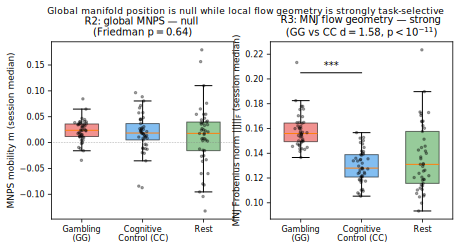


fig2_mnj_effect_sizes.svg


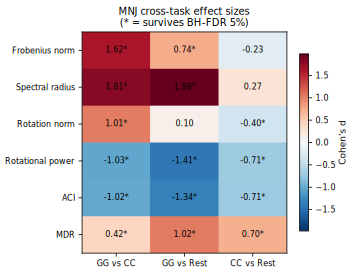


fig3_bootstrap_robustness.svg


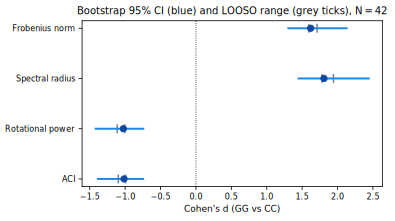


fig4_eda_dissociation.svg


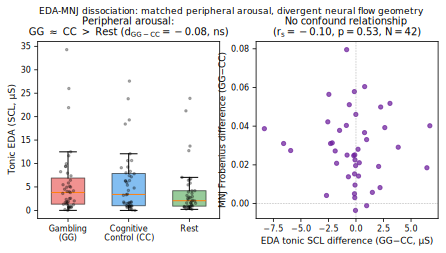


fig5_eap_resp_coupling.svg


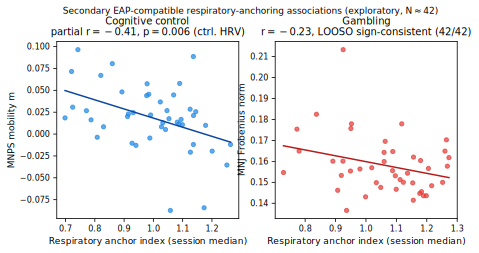


fig6_qc_coverage.svg


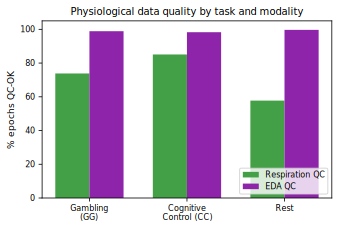

In [17]:
from IPython.display import SVG, display as ipy_display

fig_names = [
    "fig1_mnps_vs_mnj_dissociation.svg",
    "fig2_mnj_effect_sizes.svg",
    "fig3_bootstrap_robustness.svg",
    "fig4_eda_dissociation.svg",
    "fig5_eap_resp_coupling.svg",
    "fig6_qc_coverage.svg",
]
for name in fig_names:
    path = FIGDIR / name
    print(f"\n{name}")
    ipy_display(SVG(filename=str(path)))

## Section 09 — Conventional-EEG baseline comparison

**Script:** `src/09_conventional_eeg_baseline.py` · **Data:** `features.parquet` (bundled) + committed prior-run CSV (`.../05_mnj_confound_audit/intersection_sample.csv`) · **Maps to:** peer-review finding (`peer_review/pr_01.md`) — MNJ vs. conventional band-power/complexity EEG features

Runs the same GG/CC/Rest Wilcoxon contrasts on 16 conventional EEG summary
features (band power ratios, spectral entropy, etc.) already present in
`features.parquet`, and compares their effect sizes directly against the
MNJ Frobenius-norm effect from Section 03/05 — the analysis added in
response to peer review to show the flow-geometry effect is not just a
relabeling of standard EEG power changes.

In [18]:
run_script("09_conventional_eeg_baseline.py")

Loading epoch-level features ...


Found 16 conventional-EEG columns: ['eeg_conventional_complexity_hjorth_complexity', 'eeg_conventional_complexity_permutation_entropy', 'eeg_conventional_complexity_spectral_entropy', 'eeg_conventional_peak_alpha_frequency', 'eeg_conventional_peak_median_frequency', 'eeg_conventional_peak_spectral_edge_95', 'eeg_conventional_ratio_alpha_theta', 'eeg_conventional_ratio_beta_alpha', 'eeg_conventional_ratio_delta_alpha', 'eeg_conventional_ratio_slowing_index', 'eeg_conventional_ratio_theta_alpha', 'eeg_conventional_relative_alpha', 'eeg_conventional_relative_beta', 'eeg_conventional_relative_delta', 'eeg_conventional_relative_gamma', 'eeg_conventional_relative_theta']
Restricted to intersection sample: 44 subjects

--- Conventional-EEG GG/CC/Rest contrasts ---


Surviving FDR 5%: 31 / 48

GG vs CC, sorted by |Cohen's d_z|:
                                        feature  cohen_dz        p    p_fdr  sig_fdr05
                eeg_conventional_relative_theta  0.633873 0.000170 0.000354       True
             eeg_conventional_ratio_alpha_theta -0.376255 0.023629 0.037807       True
         eeg_conventional_peak_spectral_edge_95 -0.361523 0.008169 0.014522       True
             eeg_conventional_ratio_theta_alpha  0.305656 0.037434 0.056151      False
  eeg_conventional_complexity_hjorth_complexity  0.288050 0.030328 0.046959       True
                eeg_conventional_relative_alpha -0.231763 0.414375 0.452045      False
                eeg_conventional_relative_gamma -0.225375 0.063960 0.087716      False
eeg_conventional_complexity_permutation_entropy -0.220742 0.111747 0.144969      False
           eeg_conventional_ratio_slowing_index  0.218668 0.283413 0.331801      False
          eeg_conventional_peak_alpha_frequency -0.216652 0.172313 0

In [19]:
print("GG vs. CC contrasts for conventional EEG features, sorted by |Cohen's d_z|:")
display(gg_cc.head(10))

print("\nConventional-EEG vs. MNJ effect-size comparison (largest effects, both families):")
display(comp_df)

print(f"\nLargest conventional-EEG |d_z| = {max_conv_d:.3f}  vs.  MNJ Frobenius |d_z| = {mnj_frob_d:.3f}")

GG vs. CC contrasts for conventional EEG features, sorted by |Cohen's d_z|:


,feature,task1,task2,wilcoxon_stat,p,cohen_dz,n_pairs,p_fdr,sig_fdr05
45,eeg_conventional_relative_theta,gambling,cognitive_control,185.0,0.000170,0.633873,44,0.000354,True
18,eeg_conventional_ratio_alpha_theta,gambling,cognitive_control,302.0,0.023629,-0.376255,44,0.037807,True
15,eeg_conventional_peak_spectral_edge_95,gambling,cognitive_control,271.0,0.008169,-0.361523,44,0.014522,True
30,eeg_conventional_ratio_theta_alpha,gambling,cognitive_control,317.0,0.037434,0.305656,44,0.056151,False
0,eeg_conventional_complexity_hjorth_complexity,gambling,cognitive_control,310.0,0.030328,0.288050,44,0.046959,True
33,eeg_conventional_relative_alpha,gambling,cognitive_control,424.0,0.414375,-0.231763,44,0.452045,False
42,eeg_conventional_relative_gamma,gambling,cognitive_control,336.0,0.063960,-0.225375,44,0.087716,False
3,eeg_conventional_complexity_permutation_entropy,gambling,cognitive_control,358.0,0.111747,-0.220742,44,0.144969,False
27,eeg_conventional_ratio_slowing_index,gambling,cognitive_control,402.0,0.283413,0.218668,44,0.331801,False
9,eeg_conventional_peak_alpha_frequency,gambling,cognitive_control,204.5,0.172313,-0.216652,44,0.217659,False



Conventional-EEG vs. MNJ effect-size comparison (largest effects, both families):


,family,metric,cohen_dz,p,p_fdr,sig_fdr05
2,MNJ,spectral_radius,1.808162,5.684342e-13,5.570655e-12,True
0,MNJ,frobenius_norm,1.620439,7.958079e-13,5.570655e-12,True
3,MNJ,rotational_power,-1.025437,4.124058e-08,1.082565e-07,True
4,MNJ,aci,-1.015402,3.362197e-08,1.008659e-07,True
1,MNJ,rotation_norm,1.005345,2.213494e-08,7.747229e-08,True
7,conventional_eeg,eeg_conventional_relative_theta,0.633873,1.696317e-04,3.540141e-04,True
5,MNJ,mdr,0.420411,4.094120e-03,6.141181e-03,True
8,conventional_eeg,eeg_conventional_ratio_alpha_theta,-0.376255,2.362923e-02,3.780676e-02,True
9,conventional_eeg,eeg_conventional_peak_spectral_edge_95,-0.361523,8.168734e-03,1.452219e-02,True
10,conventional_eeg,eeg_conventional_ratio_theta_alpha,0.305656,3.743385e-02,5.615078e-02,False



Largest conventional-EEG |d_z| = 0.634  vs.  MNJ Frobenius |d_z| = 1.620


## Section 10 — Corrugator EMG confound control

**Script:** `src/10_corrugator_emg_confound.py` · **Data:** `features.parquet` (bundled) + committed prior-run CSVs · **Maps to:** peer-review finding — facial-muscle (corrugator EMG) tension as an alternative explanation

Checks whether corrugator EMG (a proxy for facial-muscle tension / negative
affect) tracks the GG-vs-CC MNJ effect the way EDA does not, adding a row to
the combined confound table alongside HR, respiration, EOG blink rate, and
EDA (from Section 07).

In [20]:
run_script("10_corrugator_emg_confound.py")

Loading epoch-level features ...


  EMG QC filter: kept 57526 / 57526 epochs
Restricted to intersection sample: 44 subjects

--- (a) Corrugator EMG (emg_rms) by task ---
  gambling vs cognitive_control: d_z=0.079, p=0.5059, n=44
  gambling vs rest: d_z=0.537, p=0.0003, n=44
  cognitive_control vs rest: d_z=0.567, p=0.0000, n=44

--- (b) EMG confound test for GG > CC Frobenius effect ---
Spearman(EMG_diff, Frobenius_diff): r=-0.081, p=0.6004, n=44

=== Combined confound table (HR, resp_rate, resp_anchor, EOG blink, EDA tonic, corrugator EMG) ===
             confound  r_confound_diff_x_frob_diff        p    p_fdr  sig_fdr05
  ecg_hrv_hr_mean_bpm                    -0.058069 0.708096 0.826112      False
        resp_rate_bpm                    -0.287808 0.058166 0.203580      False
    resp_anchor_index                     0.328823 0.029304 0.203580      False
       eog_blink_rate                    -0.202496 0.187422 0.437319      False
eog_artifact_fraction                          NaN      NaN 1.000000      False
   

In [21]:
print("Corrugator EMG (RMS) descriptive GG/CC/Rest contrasts:")
display(desc_df)

print(f"\nSpearman(EMG GG-CC diff, Frobenius GG-CC diff): r={r_emg:.3f}, p={p_emg:.4f}, n={n_common}")

print("\nFull confound table (HR, resp rate, resp anchor, EOG blink, EDA tonic, corrugator EMG):")
display(combined)

Corrugator EMG (RMS) descriptive GG/CC/Rest contrasts:


,task1,task2,wilcoxon_stat,p,cohen_dz,n_pairs,p_fdr,sig_fdr05
0,gambling,cognitive_control,437.0,0.505917,0.079394,44,0.505917,False
1,gambling,rest,197.0,0.000320,0.536505,44,0.000480,True
2,cognitive_control,rest,109.0,0.000001,0.566786,44,0.000003,True



Spearman(EMG GG-CC diff, Frobenius GG-CC diff): r=-0.081, p=0.6004, n=44

Full confound table (HR, resp rate, resp anchor, EOG blink, EDA tonic, corrugator EMG):


,confound,r_confound_diff_x_frob_diff,p,p_fdr,sig_fdr05
0,ecg_hrv_hr_mean_bpm,-0.058069,0.708096,0.826112,False
1,resp_rate_bpm,-0.287808,0.058166,0.203580,False
2,resp_anchor_index,0.328823,0.029304,0.203580,False
3,eog_blink_rate,-0.202496,0.187422,0.437319,False
4,eog_artifact_fraction,NaN,NaN,1.000000,False
5,eda_tonic_scl,-0.103141,0.510429,0.826112,False
6,emg_rms_corrugator,-0.081184,0.600364,0.826112,False


## Section 11 — Event-density sensitivity check

**Script:** `src/11_event_density_sensitivity.py` · **Data:** per-session HDF5 (bundled) + raw-BIDS `events.tsv` (**fetched on demand from the public OpenNeuro GitHub mirror** — see `ds004511_support.load_events()`) · **Maps to:** peer-review finding (`peer_review/pr_02.md`/`pr_03.md`) — ruling out trial/event-rate differences between GG and CC as a confound for the MNJ effect

This section exercises the GitHub-fallback path described in the intro: it
calls `load_events()` for both tasks, which will automatically fetch and
cache each subject's small `events.tsv` file
(`data/external_cache/ds004511_events/`) if no local raw-BIDS mirror is
present. Expect this to take **1-3 minutes on first run** (~130 small HTTP
requests) and to be near-instant afterwards.

In [22]:
run_script("11_event_density_sensitivity.py")

Intersection sample: 44 subjects

--- A. Loading Sync(1) event onsets from raw events.tsv ---


  GG: 56534 Sync pulses across 44 subjects


  CC: 21150 Sync pulses across 45 subjects


  Rest: 80 Sync pulses across 45 subjects

--- B. Session-level event rate and epoch-level event density ---


                  event_rate_hz                                                  median_epoch_event_count                                      
                          count   mean    std    min    25%    50%    75%    max                    count   mean   std  min  25%  50%  75%  max
task_label                                                                                                                                     
cognitive_control          44.0  0.455  0.028  0.352  0.441  0.453  0.475  0.519                     44.0  4.182  0.39  4.0  4.0  4.0  4.0  5.0
gambling                   44.0  0.354  0.017  0.279  0.345  0.357  0.365  0.376                     44.0  3.000  0.00  3.0  3.0  3.0  3.0  3.0
rest                       44.0  0.003  0.009  0.002  0.002  0.002  0.002  0.062                     44.0  0.000  0.00  0.0  0.0  0.0  0.0  0.0

--- B2. Event-rate contrasts by task pair ---
  gambling vs cognitive_control: event_rate d_z=-3.995, p=0.0000, n=44  (median gambling=

In [23]:
print("Event-rate (button-press density) GG vs. CC vs. Rest contrasts:")
display(rate_res)

print(f"\nSpearman(event-rate GG-CC diff, Frobenius GG-CC diff): r={r_rate:.3f}, p={p_rate:.4f}")
print("(a small/non-significant r means the MNJ effect isn't just tracking how often subjects act)")

print("\nEvent-density-matched (low-density-epochs-only) GG vs. CC Frobenius contrast:")
display(gg_cc_density)

print("\nFinal combined confound table (adds event rate to HR/resp/EOG/EDA/EMG):")
display(combined)

Event-rate (button-press density) GG vs. CC vs. Rest contrasts:


,task1,task2,cohen_dz,p,n_pairs,median_t1_hz,median_t2_hz,p_fdr,sig_fdr05
0,gambling,cognitive_control,-3.995214,1.136868e-13,44,0.356691,0.452519,1.136868e-13,True
1,gambling,rest,19.795902,1.136868e-13,44,0.356691,0.002033,1.136868e-13,True
2,cognitive_control,rest,16.294446,1.136868e-13,44,0.452519,0.002033,1.136868e-13,True



Spearman(event-rate GG-CC diff, Frobenius GG-CC diff): r=-0.046, p=0.7664
(a small/non-significant r means the MNJ effect isn't just tracking how often subjects act)

Event-density-matched (low-density-epochs-only) GG vs. CC Frobenius contrast:


,task1,task2,cohen_dz,p,n_pairs,median_n_epochs_t1,median_n_epochs_t2,p_fdr,sig_fdr05
0,gambling,cognitive_control,1.694697,3.410605e-13,44,644.0,161.5,1.023182e-12,True



Final combined confound table (adds event rate to HR/resp/EOG/EDA/EMG):


,confound,r_confound_diff_x_frob_diff,p,p_fdr,sig_fdr05
0,ecg_hrv_hr_mean_bpm,-0.058069,0.708096,0.875896,False
1,resp_rate_bpm,-0.287808,0.058166,0.232663,False
2,resp_anchor_index,0.328823,0.029304,0.232663,False
3,eog_blink_rate,-0.202496,0.187422,0.499793,False
4,eog_artifact_fraction,NaN,NaN,1.000000,False
5,eda_tonic_scl,-0.103141,0.510429,0.875896,False
6,emg_rms_corrugator,-0.081184,0.600364,0.875896,False
7,event_rate_hz,-0.046089,0.766409,0.875896,False


## Claim ledger — manuscript results → notebook section → data requirement

Use this table to jump straight to the section that reproduces a specific
claim in the manuscript.

| Result | Claim | Section | Data requirement |
| --- | --- | --- | --- |
| R1 | Sample composition, epoch coverage, QC pass rates define the analysis sample | [00](#Section-00-—-Sanity-check-/-QC-audit) | bundled (`features.parquet`) |
| R2 | Global manifold geometry (MNPS) does **not** differ across GG / CC / Rest | [01](#Section-01-—-Cross-task-MNPS-geometry-(global-manifold-coordinates)) | bundled (cohort CSVs) |
| — | Embodied Anchoring Principle: exploratory physio↔geometry couplings (secondary) | [02](#Section-02-—-Embodied-Anchoring-Principle-(EAP)-physio-geometry-coupling) | bundled (`features.parquet` + cohort CSVs) |
| R3 | **Primary finding** — local flow-geometry (MNJ Frobenius norm) is markedly larger in GG than CC | [03](#Section-03-—-Epoch-level-MNJ-(local-flow-geometry)-extraction) | bundled (HDF5 Jacobians + `features.parquet`) |
| R4 | The GG vs. CC MNJ effect survives intersection/epoch-matched resampling, LOOSO, bootstrap, permutation, and artifact/physio-confound checks | [05](#Section-05-—-MNJ-robustness-/-confound-audit) | bundled (HDF5 + `features.parquet`) |
| — | Raw EDA feature extraction (feeds R5) | [06](#Section-06-—-EDA-feature-extraction-(special-cased:-raw-physio-not-bundled)) | **external-only** (raw BioPac physio); committed output used as fallback |
| R5 | Sympathetic arousal (EDA) does **not** track the GG vs. CC flow-geometry effect ("... despite matched sympathetic arousal") | [07](#Section-07-—-EDA-vs.-MNJ-dissociation-(arousal-confound-control)) | committed-only (prior-run CSVs) |
| — | Manuscript Figures 1-6 | [08](#Section-08-—-Manuscript-figure-generation) | committed-only (prior-run CSVs) |
| — | Conventional band-power/complexity EEG effects are smaller than the MNJ effect (peer-review addition) | [09](#Section-09-—-Conventional-EEG-baseline-comparison) | bundled (`features.parquet`) |
| — | Corrugator EMG (facial tension) does not explain the MNJ effect (peer-review addition) | [10](#Section-10-—-Corrugator-EMG-confound-control) | bundled (`features.parquet`) + committed-only |
| — | Event/trial-rate differences do not explain the MNJ effect (peer-review addition) | [11](#Section-11-—-Event-density-sensitivity-check) | bundled (HDF5) + network-fetch (GitHub `events.tsv`) |

**Legend — data requirement:**
- **bundled**: everything needed ships in this repository (`data/raw/`, `data/processed/`); runs offline, from a clean checkout.
- **committed-only**: reads fixed intermediate CSVs already committed under `results/ds004511_20260701/` / `..._20260702/`; runs offline.
- **network-fetch**: needs internet access to fetch small (~20-50 KB) files from the public OpenNeuro GitHub mirror on first run (then cached locally).
- **external-only**: genuinely cannot be reproduced from this repository alone (raw BioPac physio, tens of GB); documented, not silently skipped.